In [ ]:
# Questions
# 1. How accurately do different tools estimate virus diversity/abundance?
# 2. How accurately can different tools detect virus fragmentation?
# 3. How accurately can different tools recover virus strain variation?

# Setup
# 1. Extract HQ viruses from comprehensivity benchmark for each body site
# 2. Cluster into vOTUs within each body site
# 3. Randomly split HQ viruses into 5 sets for each body site (20 total sets)
# 4. Randomly split each set into 5 parts, and fragment genomes at 20, 40, 60, 80, and 100% (100% = no fragmentation)
# 5. Simulate reads from each fragmented set at different read depths (1M, 5M, 10M, 20M, 50M)

In [ ]:
# ### Extract HQ viruses from comprehensivity benchmark for each body site ###
# import polars as pl

# # load samplesheets
# gut_samplesheet = pl.read_csv('gut_samplesheet.csv').with_columns([pl.lit('gut').alias('body_site')])
# oral_samplesheet = pl.read_csv('oral_samplesheet.csv').with_columns([pl.lit('oral').alias('body_site')])
# skin_samplesheet = pl.read_csv('skin_samplesheet.csv').with_columns([pl.lit('skin').alias('body_site')])
# urogenital_samplesheet = pl.read_csv('urogenital_samplesheet.csv').with_columns([pl.lit('urogenital').alias('body_site')])
# combined_samplesheet = pl.concat([gut_samplesheet, oral_samplesheet, skin_samplesheet, urogenital_samplesheet])

# # !grep "^>" combined_renamed.fna > combined_renamed.fna.ids

# # assign sequences to body sites
# seq2site = (
#     pl.read_csv('combined_renamed.fna.ids', has_header=False)
#         .rename({'column_1': 'qname'})
#         .with_columns([
#             pl.col('qname').str.split('_k').list[0].str.replace('>', '').alias('acc'),
#             pl.col('qname').str.replace('>', '').str.split(' ').list[0]
#         ])
#         .join(combined_samplesheet, on='acc', how='inner')
# )

# # write out body site specific sequence ids
# for site in ['gut', 'oral', 'skin', 'urogenital']:
#     seq2site.filter(pl.col('body_site') == site).select('qname').write_csv(f'{site}_hq_virus_ids.txt')

# # create body site specific fasta files
# !for site in gut oral skin urogenital; do \
#     mkdir -p ${site}_hq_viruses; \
#     seqkit grep \
#         combined_renamed.fna \
#         --pattern-file ${site}_hq_virus_ids.txt \
#         -o ${site}_hq_viruses/${site}_hq_viruses.fna; \
# done

mkdir: missing operand
Try 'mkdir --help' for more information.
[ERRO] stat .txt: no such file or directory
mkdir: missing operand
Try 'mkdir --help' for more information.
[ERRO] stat .txt: no such file or directory
mkdir: missing operand
Try 'mkdir --help' for more information.
[ERRO] stat .txt: no such file or directory
mkdir: missing operand
Try 'mkdir --help' for more information.
[ERRO] stat .txt: no such file or directory


In [ ]:
%%bash
### Cluster into vOTUs within each body site ###

# for site in gut oral skin urogenital; do
    # vclust \
    #     prefilter \
    #     --in ${site}_hq_viruses/${site}_hq_viruses.fna \
    #     --out ${site}_hq_viruses/${site}.vclust_prefilter.txt \
    #     --threads 48 \
    #     --min-ident 0.95

    # vclust \
    #     align \
    #     --in ${site}_hq_viruses/${site}_hq_viruses.fna \
    #     --out ${site}_hq_viruses/${site}.vclust_ani.tsv \
    #     --filter ${site}_hq_viruses/${site}.vclust_prefilter.txt \
    #     --threads 48 \
    #     --out-ani 0.95 \
    #     --out-qcov 0.85

    # vclust \
    #     cluster \
    #     --in ${site}_hq_viruses/${site}.vclust_ani.tsv\
    #     --ids ${site}_hq_viruses/${site}.vclust_ani.ids.tsv \
    #     --out ${site}_hq_viruses/${site}.vclust_clusters.tsv \
    #     --algorithm cd-hit \
    #     --metric ani \
    #     --ani 0.995 \
    #     --qcov 1.0 \
    #     --out-repr

#     csvtk \
#         cut \
#         ${site}_hq_viruses/${site}.vclust_clusters.tsv \
#         --tabs \
#         --fields cluster | \
#     csvtk \
#         uniq \
#         --tabs \
#         --out-file ${site}_hq_viruses/${site}.vclust_reps.tsv

#     seqkit \
#         grep \
#         ${site}_hq_viruses/${site}_hq_viruses.fna \
#         --pattern-file ${site}_hq_viruses/${site}.vclust_reps.tsv \
#         --out-file ${site}_hq_viruses/${site}_reps.fna
# done

In [ ]:
%%bash
### Split clustered viruses into splits of 100 sequences  ###
# for site in gut oral skin urogenital; do

    # mkdir -p ${site}_hq_viruses/${site}_reps_split

    # seqkit split2 \
    #     ${site}_hq_viruses/${site}_reps.fna \
    #     --by-size 100 \
    #     --out-dir ${site}_hq_viruses/${site}_reps_split

#     for file in ${site}_hq_viruses/${site}_reps_split/*.fna; do
#         seqkit fx2tab \
#             ${file} \
#             --name \
#             --only-id \
#             --length \
#             -o ${file}.lengths.txt
#     done
# done

In [ ]:
%%bash
# ### Simulate reads from each fragmented set at different read depths (100K, 1M, 5M) ###
# sbatch read_simulation.sh

In [ ]:
# count reads derived from each reference
import gzip
import os
import polars as pl

# for i in range(1, 18):

#     if os.path.exists(f'readsim/split_{i}_reads_cov.txt'):
#         print(f'Coverage file readsim/split_{i}_reads_cov.txt already exists, skipping...')
#         continue

#     genome_read_counts = {}
#     with open(f'readsim/split_{i}_reads_abundance.txt', 'r') as f:
#         for line in f.readlines():
#             genome_read_counts[line.split('\t')[0]] = 0

#     with gzip.open(f'readsim/split_{i}_reads_R1.fastq.gz', 'rt') as f:
#         for line in f.readlines():
#             if line.startswith('@'):
#                 genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

#     with gzip.open(f'readsim/split_{i}_reads_R1.fastq.gz', 'rt') as f:
#         for line in f.readlines():
#             if line.startswith('@'):
#                 genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

#     # calculate coverage for each reference
#     if i < 10:
#         body_site = "gut"
#         j = i

#         meta = (
#             pl.read_csv(f'{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_00{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
#                 .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
#                 .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
#                 .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
#                 .rename({
#                     'contig_id': 'tname',
#                     'length': 'genome_length'
#                 })
#         )

#     if i == 10:
#         body_site = "gut"
#         j = i

#         meta = (
#             pl.read_csv(f'{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_0{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
#                 .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
#                 .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
#                 .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
#                 .rename({
#                     'contig_id': 'tname',
#                     'length': 'genome_length'
#                 })
#         )

#     if i > 10:
#         if i < 15:
#             body_site = "oral"
#             j = i - 10
#         elif i < 17:
#             body_site = "skin"
#             j = i - 14
#         else:
#             body_site = "urogenital"
#             j = i - 16

#         meta = (
#             pl.read_csv(f'{body_site}_hq_viruses/{body_site}_reps_split/{body_site}_reps.part_00{j}.fna.lengths.txt', has_header=False, separator='\t', new_columns=['contig_id', 'length'])
#                 .filter(pl.col('contig_id').is_in(genome_read_counts.keys()))
#                 .with_columns(read_count=pl.col('contig_id').replace_strict(genome_read_counts, return_dtype=pl.Int64))
#                 .with_columns(coverage=pl.col('read_count') * 300 / pl.col('length'))
#                 .rename({
#                     'contig_id': 'tname',
#                     'length': 'genome_length'
#                 })
#         )

#     # write out coverage file
#     meta.write_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t')

Coverage file readsim/split_1_reads_cov.txt already exists, skipping...
Coverage file readsim/split_2_reads_cov.txt already exists, skipping...
Coverage file readsim/split_3_reads_cov.txt already exists, skipping...
Coverage file readsim/split_4_reads_cov.txt already exists, skipping...
Coverage file readsim/split_5_reads_cov.txt already exists, skipping...
Coverage file readsim/split_6_reads_cov.txt already exists, skipping...
Coverage file readsim/split_7_reads_cov.txt already exists, skipping...
Coverage file readsim/split_8_reads_cov.txt already exists, skipping...
Coverage file readsim/split_9_reads_cov.txt already exists, skipping...
Coverage file readsim/split_10_reads_cov.txt already exists, skipping...


In [ ]:
%%bash
# # run baqlava
# for i in {2..17}; do
#     mkdir -p uhvdb_baqlava/split_${i}

#     cat readsim/split_${i}_reads_R1.fastq.gz readsim/split_${i}_reads_R2.fastq.gz > readsim/split_${i}_reads.fastq.gz

#     baqlava \
#         --nucdb /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/baqlava_db/data/BAQLaVa.V0.5.nucleotide \
#         --protdb /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/baqlava_db/data/BAQLaVa.V0.5.protein \
#         --bypass-bacterial-depletion \
#         --input readsim/split_${i}_reads.fastq.gz \
#         --output uhvdb_baqlava/split_${i} \
#         --threads 32
# done

# # blast assembled genomes vs baqlava
# makeblastdb \
#     -in /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/baqlava_db/data/BAQLaVa.V0.5.raw_databases/BAQLaVa_nucleotidedb_dereplicated.fasta \
#     -dbtype nucl \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/baqlava_db/BAQLaVa_nucleotidedb_dereplicated.blastdb

# # align sequences to UHVDB HQ vOTU reps
# blastn \
#     -query /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/combined_renamed.fna \
#     -db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/baqlava_db/BAQLaVa_nucleotidedb_dereplicated.blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 10000 \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_baqlava/combined_renamed_v_baqlava_derep.blast.tsv \
#     -num_threads 4

# python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
#     -i /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_baqlava/combined_renamed_v_baqlava_derep.blast.tsv \
#     -o /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv

In [ ]:
%%bash
# mkdir -p uhvdb_phanta/results

# modified sample file here: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/samp_file.txt
# modified config file here: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/config.yaml

# # run phanta
# snakemake \
#     -s /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/phanta/Snakefile \
#     --configfile /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/config.yaml \
#     --jobs 99 \
#     --cores 32 \
#     --max-threads 8


# # blast assembled genomes vs phanta
# makeblastdb \
#     -in /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/phanta/phanta_dbs/votus_hq_plus.fna \
#     -dbtype nucl \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/phanta/phanta_dbs/votus_hq_plus.blastdb

# blastn \
#     -query /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/combined_renamed.fna \
#     -db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/phanta/phanta_dbs/votus_hq_plus.blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 10000 \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/combined_renamed_v_votus_hq_plus.blast.tsv \
#     -num_threads 48

# python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
#     -i /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/combined_renamed_v_votus_hq_plus.blast.tsv \
#     -o /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv

In [ ]:
%%bash

# # run marker magu
# mkdir -p markermagu


# for i in {2..17}; do
#     gunzip readsim/split_${i}_reads_R*.fastq.gz

#     markermagu \
#         --cpu 32 \
#         --keep True \
#         --db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/v1.1 \
#         --detection default \
#         --reads readsim/split_${i}_reads_R1.fastq readsim/split_${i}_reads_R2.fastq \
#         --sample split_${i} \
#         --output_dir markermagu/split_${i}

#     gzip readsim/split_${i}_reads_R1.fastq
#     gzip readsim/split_${i}_reads_R2.fastq
# done


# # blast assembled genomes vs tvgv
# makeblastdb \
#     -in /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/v1.1/TGVG_v1.1.genomes.all.fna \
#     -dbtype nucl \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/TGVG_v1.1.genomes.all.blastdb

# blastn \
#     -query /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/combined_renamed.fna \
#     -db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/TGVG_v1.1.genomes.all.blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 10000 \
#     -out /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/markermagu/combined_renamed_v_tgvg.blast.tsv \
#     -num_threads 48

# python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/anicalc.py \
#     -i /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/markermagu/combined_renamed_v_tgvg.blast.tsv \
#     -o /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/gut_microbiome_test/markermagu/combined_renamed_v_tgvg.anicalc.tsv

In [ ]:
%%bash
# # sylph profile + strobealign
# sylph sketch \
#     --genomes /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_09/uhvdb_votu_reps.fna.gz \
#     -t 48 \
#     --individual-records \
#     --out-name-db uhvdb_r2025_09.votu_reps.c200 \
#     -c 200

# for i in {1..17}; do

#     mkdir -p uhvdb_sylph_profile/split_${i}

#     sylph profile \
#         uhvdb_r2025_09.votu_reps.c200.syldb \
#         globdb_r226_sylph_c1000.syldb \
#         -1 readsim/split_${i}_reads_R1.fastq.gz \
#         -2 readsim/split_${i}_reads_R2.fastq.gz \
#         --output-file uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.profile.tsv \
#         -t 32 \
#         --min-number-kmers 3 \
#         --estimate-unknown > uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.profile.log 2>&1

# done

# copy blast results to cwd (blast already completed for comprehensivity)
# cp ../../figure_2/uhvdb.anicalc.tsv .

Detected species > 0x- gut: 845 oral: 323 skin: 145 urogenital: 81
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 50
R-squared: PearsonRResult(statistic=np.float64(0.9731690817586088), pvalue=np.float64(0.0))


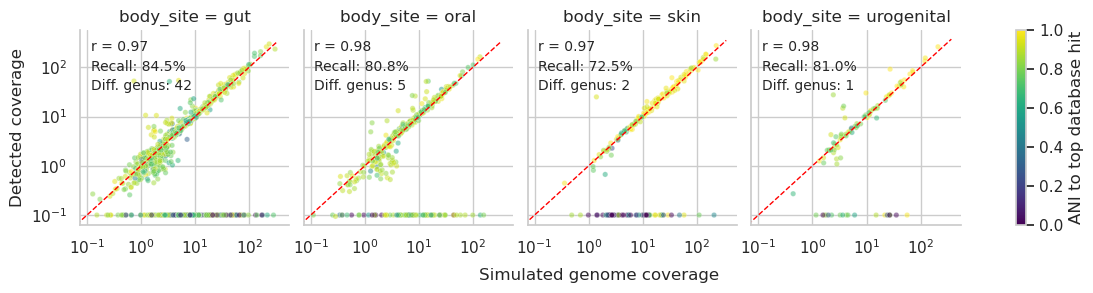

In [14]:
# sylph profile
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob

cov_lst = []
for file in glob.glob('readsim/split_*_reads_cov.txt'):
    df = pl.read_csv(file, separator='\t').rename({'tname':'qname'})
    i = int(file.split('split_')[1].split('_')[0])

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"

    cov_lst.append(
        df
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )
cov_df = pl.concat(cov_lst)

df_lst = []

for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani') # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load sylph data
    sylph_top_hit = (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True) # load sylph data
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            .filter(pl.col('Adjusted_ANI') >= 95)
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), left_on='contig_id', right_on='tname', how='left') # keep blast data for sylph hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only sylph v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of sylph (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each sylph genome
            .unique('contig_id', maintain_order=True) # keep only top input per sylph genome
            [['contig_id', 'qname', 'True_cov', 'Adjusted_ANI']]
    )

    # assign sylph coverages to input genome
    input_w_sylph = (
        input_genomes
            .join(sylph_top_hit, on='qname', how='left') # add sylph data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple sylph to an input, keep only sylph for top database hit
            .fill_null(0.1) # fill missing sylph hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_sylph
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('True_cov') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('True_cov') > 0.1))['coverage'].to_list(), df.filter((pl.col('True_cov') > 0.1))['True_cov'].to_list()))

# plot breadth results
df = df.rename({'True_cov':'Detected coverage', 'coverage':'Simulated genome coverage'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Simulated genome coverage', 'Detected coverage', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# display r on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Simulated genome coverage'].to_list(),
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Detected coverage'].to_list()
    )[0]
    tp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Simulated genome coverage', ha='center', fontsize=12)

plt.show()

Detected species > 0x- gut: 0 airways: 242 skin: 0 urogenital: 0
Total species > 0x - gut: 0 airways: 300 skin: 0 urogenital: 0
False hits: 5
R-squared: PearsonRResult(statistic=np.float64(0.9773612178971637), pvalue=np.float64(6.822310301762778e-164))


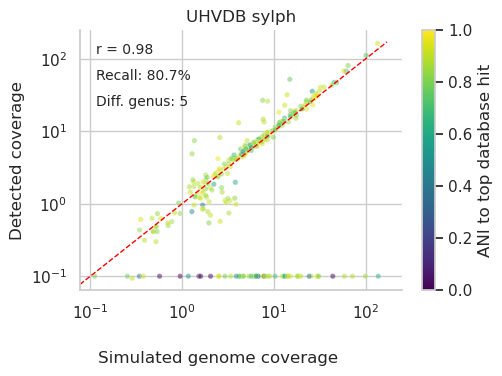

In [15]:
# sylph profile (figure 5B)
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob

df_lst = []

for i in range(11, 14):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani') # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load sylph data
    sylph_top_hit = (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True) # load sylph data
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            .filter(pl.col('Adjusted_ANI') >= 95)
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), left_on='contig_id', right_on='tname', how='left') # keep blast data for sylph hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only sylph v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of sylph (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each sylph genome
            .unique('contig_id', maintain_order=True) # keep only top input per sylph genome
            [['contig_id', 'qname', 'True_cov', 'Adjusted_ANI']]
    )

    # assign sylph coverages to input genome
    input_w_sylph = (
        input_genomes
            .join(sylph_top_hit, on='qname', how='left') # add sylph data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple sylph to an input, keep only sylph for top database hit
            .fill_null(0.1) # fill missing sylph hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "airways"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_sylph
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "airways:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('True_cov') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "airways:", df.filter((pl.col('body_site') == 'airways')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('True_cov') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('True_cov') > 0.1))['coverage'].to_list(), df.filter((pl.col('True_cov') > 0.1))['True_cov'].to_list()))

# plot breadth results
df = df.rename({'True_cov':'Detected coverage', 'coverage':'Simulated genome coverage'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Simulated genome coverage', 'Detected coverage', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Simulated genome coverage', ha='center', fontsize=12)

# display r on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Simulated genome coverage'].to_list(),
        df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site))['Detected coverage'].to_list()
    )[0]
    tp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected coverage') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# increase plot size
g.fig.set_size_inches(6, 4)

# remove body site titles
for ax in g.axes.flat:
    ax.set_title('UHVDB sylph')

plt.show()

Detected species > 0x- gut: 663 oral: 147 skin: 72 urogenital: 28
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 41
R-squared: PearsonRResult(statistic=np.float64(0.584698533073819), pvalue=np.float64(1.4713858374657934e-84))


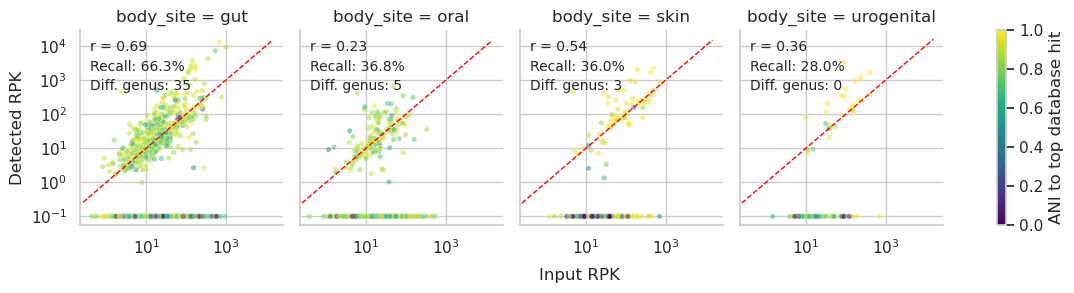

In [21]:
# baqlava
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

cov_lst = []
for file in glob.glob('readsim/split_*_reads_cov.txt'):
    df = pl.read_csv(file, separator='\t').rename({'tname':'qname'})
    i = int(file.split('split_')[1].split('_')[0])

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"

    # convert coverage to rpk
    cov_lst.append(
        df
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
            .with_columns([
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
    )
cov_df = pl.concat(cov_lst)

df_lst = []


for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname),
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load baqlava data
    baqlava_top_hit = (
        pl.read_csv(f'uhvdb_baqlava/split_{i}/split_{i}_reads_BAQLaVa_profile.txt', separator='\t', ignore_errors=True) # load baqlava data
            .filter(~pl.col('BAQLaVa VGB').str.contains('\\|'))
            .with_columns([
                pl.col(f'split_{i}_reads_Abundance-RPKs').alias('rpk'),
                pl.col('BAQLaVa VGB').alias('contig_id')
            ])
            .join(
                pl.read_csv('baqlava_db/BAQLaVa_metadata_genomes.txt', separator='\t')[['Genome Name', 'VGB']],
                left_on='contig_id',
                right_on='VGB',
                how='left'
            )
            .join(pl.read_csv('uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for baqlava hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only baqlava v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of baqlava (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each baqlava genome
            .unique('contig_id', maintain_order=True) # keep only top input per baqlava genome
            [['contig_id', 'qname', 'rpk']]
    )

    # assign baqlava coverages to input genome
    input_w_baqlava = (
        input_genomes
            .join(baqlava_top_hit, on='qname', how='left') # add baqlava data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple baqlava to an input, keep only baqlava for top database hit
            .fill_null(0.1) # fill missing baqlava hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"

    final_df = (
        input_w_baqlava
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('input_rpk') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpk') > 0.1))['input_rpk'].to_list(), df.filter((pl.col('rpk') > 0.1))['rpk'].to_list()))


# plot breadth results
df = df.rename({'rpk':'Detected RPK', 'input_rpk':'Input RPK'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPK', 'Detected RPK', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# display r on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Input RPK'].to_list(),
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Detected RPK'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')


# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPK', ha='center', fontsize=12)

plt.show()

Detected species > 0x- gut: 0 oral: 147 skin: 0 urogenital: 0
Total species > 0x - gut: 0 oral: 400 skin: 0 urogenital: 0
False hits: 6
R-squared: PearsonRResult(statistic=np.float64(0.22636527524854463), pvalue=np.float64(0.005833709933947692))


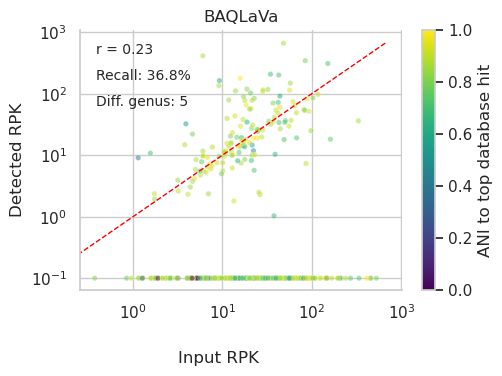

In [20]:
# baqlava (Figure 5B)
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

cov_lst = []
for file in glob.glob('readsim/split_*_reads_cov.txt'):
    df = pl.read_csv(file, separator='\t').rename({'tname':'qname'})
    i = int(file.split('split_')[1].split('_')[0])

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"

    # convert coverage to rpk
    cov_lst.append(
        df
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
            .with_columns([
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
    )
cov_df = pl.concat(cov_lst)

df_lst = []


for i in range(11, 15):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('uhvdb.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname),
                ((pl.col('coverage') * 1000) / (300)).alias('input_rpk')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load baqlava data
    baqlava_top_hit = (
        pl.read_csv(f'uhvdb_baqlava/split_{i}/split_{i}_reads_BAQLaVa_profile.txt', separator='\t', ignore_errors=True) # load baqlava data
            .filter(~pl.col('BAQLaVa VGB').str.contains('\\|'))
            .with_columns([
                pl.col(f'split_{i}_reads_Abundance-RPKs').alias('rpk'),
                pl.col('BAQLaVa VGB').alias('contig_id')
            ])
            .join(
                pl.read_csv('baqlava_db/BAQLaVa_metadata_genomes.txt', separator='\t')[['Genome Name', 'VGB']],
                left_on='contig_id',
                right_on='VGB',
                how='left'
            )
            .join(pl.read_csv('uhvdb_baqlava/combined_renamed_v_baqlava_derep.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for baqlava hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only baqlava v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of baqlava (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each baqlava genome
            .unique('contig_id', maintain_order=True) # keep only top input per baqlava genome
            [['contig_id', 'qname', 'rpk']]
    )

    # assign baqlava coverages to input genome
    input_w_baqlava = (
        input_genomes
            .join(baqlava_top_hit, on='qname', how='left') # add baqlava data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple baqlava to an input, keep only baqlava for top database hit
            .fill_null(0.1) # fill missing baqlava hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"

    final_df = (
        input_w_baqlava
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)

print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpk') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('input_rpk') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpk') > 0.1))['input_rpk'].to_list(), df.filter((pl.col('rpk') > 0.1))['rpk'].to_list()))


# plot breadth results
df = df.rename({'rpk':'Detected RPK', 'input_rpk':'Input RPK'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPK', 'Detected RPK', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))


# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPK', ha='center', fontsize=12)

# display r-squared on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r_squared = pearsonr(
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Input RPK'].to_list(),
        df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site))['Detected RPK'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r_squared:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPK') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# increase plot size
g.fig.set_size_inches(6, 4)

# remove body site titles
for ax in g.axes.flat:
    ax.set_title('BAQLaVa')

plt.show()

Detected species > 0x- gut: 356 oral: 173 skin: 37 urogenital: 31
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 46
R-squared: PearsonRResult(statistic=np.float64(0.5659651409595926), pvalue=np.float64(7.437428503048128e-52))


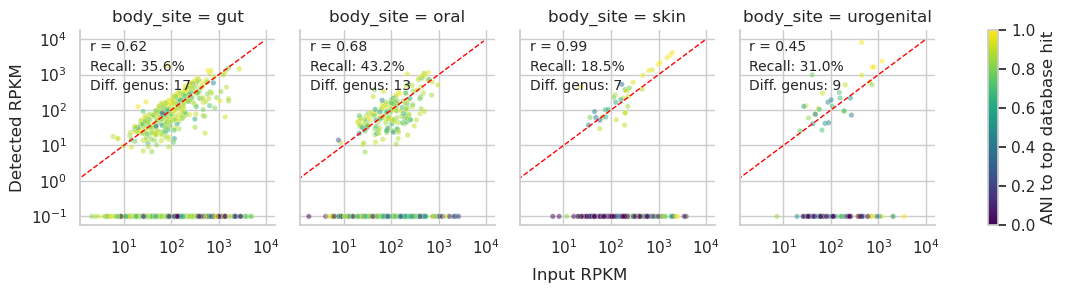

In [22]:
# marker-magu
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
                ((pl.col('coverage') * 1e9) / (600 * 100000)).alias('input_rpkm')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load magu data
    magu_top_hit = (
        pl.read_csv(f'markermagu/split_{i}/split_{i}.detected_species.tsv', separator='\t', ignore_errors=True) # load magu data
            .with_columns([
                pl.col('RPKM').alias('rpkm'),
                pl.col('lineage').str.split('s__').list[1].alias('contig_id')
            ])
            .join(
                pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/v1.1/TGVG_v1.1_metadata.tsv', ignore_errors=True, separator='\t')
                    .with_columns([
                        pl.col('lineage').str.split('s_').list[1].alias('lineage')
                    ])
                    .rename({'contig_id': 'Genome Name'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for magu hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only magu v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of magu (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each magu genome
            .unique('contig_id', maintain_order=True) # keep only top input per magu genome
            [['contig_id', 'qname', 'rpkm']]
    )

    # assign magu coverages to input genome
    input_w_magu = (
        input_genomes
            .join(magu_top_hit, on='qname', how='full') # add magu data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple magu to an input, keep only magu for top database hit
            .fill_null(0.1) # fill missing magu hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_magu
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('rpkm') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpkm') > 0.1))['coverage'].to_list(), df.filter((pl.col('rpkm') > 0.1))['rpkm'].to_list()))

# plot breadth results
df = df.rename({'rpkm':'Detected RPKM', 'input_rpkm':'Input RPKM'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPKM', 'Detected RPKM', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site))['Input RPKM'].to_list(),
        df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site))['Detected RPKM'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPKM', ha='center', fontsize=12)

plt.show()

Detected species > 0x- gut: 0 oral: 173 skin: 0 urogenital: 0
Total species > 0x - gut: 0 oral: 400 skin: 0 urogenital: 0
False hits: 13
R-squared: PearsonRResult(statistic=np.float64(0.6784507541489501), pvalue=np.float64(1.1213453895342053e-24))


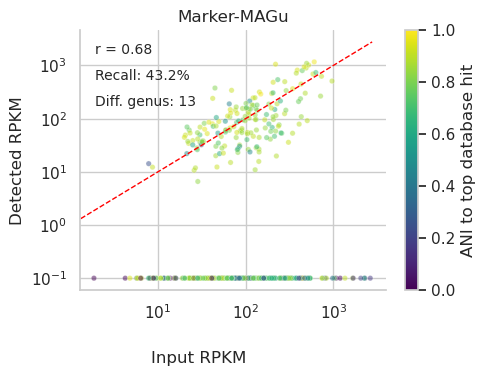

In [23]:
# marker-magu (Figure 5B)
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(11, 15):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a sylph genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
                ((pl.col('coverage') * 1e9) / (600 * 100000)).alias('input_rpkm')
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load magu data
    magu_top_hit = (
        pl.read_csv(f'markermagu/split_{i}/split_{i}.detected_species.tsv', separator='\t', ignore_errors=True) # load magu data
            .with_columns([
                pl.col('RPKM').alias('rpkm'),
                pl.col('lineage').str.split('s__').list[1].alias('contig_id')
            ])
            .join(
                pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/marker_magu/v1.1/TGVG_v1.1_metadata.tsv', ignore_errors=True, separator='\t')
                    .with_columns([
                        pl.col('lineage').str.split('s_').list[1].alias('lineage')
                    ])
                    .rename({'contig_id': 'Genome Name'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for magu hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only magu v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of magu (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each magu genome
            .unique('contig_id', maintain_order=True) # keep only top input per magu genome
            [['contig_id', 'qname', 'rpkm']]
    )

    # assign magu coverages to input genome
    input_w_magu = (
        input_genomes
            .join(magu_top_hit, on='qname', how='full') # add magu data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple magu to an input, keep only magu for top database hit
            .fill_null(0.1) # fill missing magu hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_magu
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('rpkm') > 0.1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('rpkm') > 0.1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('rpkm') > 0.1))['coverage'].to_list(), df.filter((pl.col('rpkm') > 0.1))['rpkm'].to_list()))

# plot breadth results
df = df.rename({'rpkm':'Detected RPKM', 'input_rpkm':'Input RPKM'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input RPKM', 'Detected RPKM', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input RPKM', ha='center', fontsize=12)

# display r-squared on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r_squared = pearsonr(
        df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site))['Input RPKM'].to_list(),
        df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site))['Detected RPKM'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r_squared:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Detected RPKM') > 0.1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# increase plot size`
g.fig.set_size_inches(6, 4)

# remove body site titles
for ax in g.axes.flat:
    ax.set_title('Marker-MAGu')

plt.show()

Detected species > 0x- gut: 311 oral: 116 skin: 39 urogenital: 22
Total species > 0x - gut: 1000 oral: 400 skin: 200 urogenital: 100
False hits: 39
R-squared: PearsonRResult(statistic=np.float64(0.48650592624331757), pvalue=np.float64(2.3178838700498287e-30))


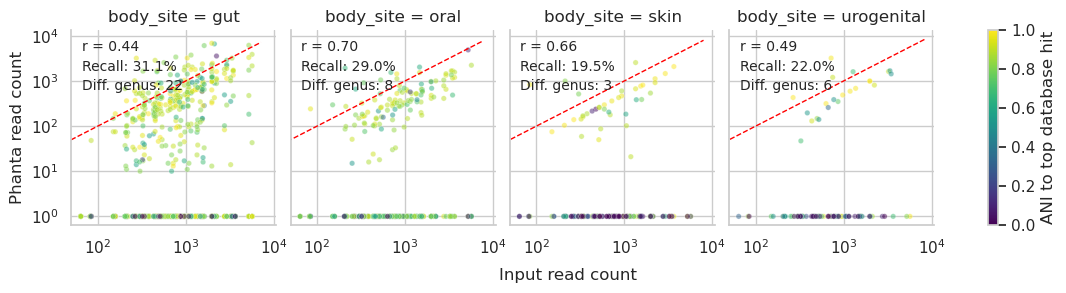

In [ ]:
# phanta
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(1, 18):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a phanta genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load phanta data
    phanta_top_hit = (
        pl.read_csv(f'uhvdb_phanta/results/classification/split_{i}.krak.report.filtered.bracken.scaled', separator='\t', ignore_errors=True) # load phanta data
            .rename({'name':'contig_id'})
            .with_columns([
                (pl.col('new_est_reads') * 2).alias('phanta_read_count'),
            ])
            .join(
                pl.read_csv('uhvdb_phanta/votus_metadata.tsv', ignore_errors=True, separator='\t')
                    .rename({'uhgv_genome': 'Genome Name', 'uhgv_votu':'lineage'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for phanta hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only phanta v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of phanta (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each phanta genome
            .unique('contig_id', maintain_order=True) # keep only top input per phanta genome
            [['contig_id', 'qname', 'phanta_read_count']]
    )

    # assign phanta coverages to input genome
    input_w_phanta = (
        input_genomes
            .join(phanta_top_hit, on='qname', how='full') # add phanta data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple phanta to an input, keep only phanta for top database hit
            .fill_null(1) # fill missing phanta hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_phanta
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('phanta_read_count') > 1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('phanta_read_count') > 1))['read_count'].to_list(), df.filter((pl.col('phanta_read_count') > 1))['phanta_read_count'].to_list()))

# plot breadth results
df = df.rename({'phanta_read_count':'Phanta read count', 'read_count':'Input read count'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input read count', 'Phanta read count', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r = pearsonr(
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Input read count'].to_list(),
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Phanta read count'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input read count', ha='center', fontsize=12)

plt.show()

Detected species > 0x- gut: 0 oral: 116 skin: 0 urogenital: 0
Total species > 0x - gut: 0 oral: 400 skin: 0 urogenital: 0
False hits: 8
R-squared: PearsonRResult(statistic=np.float64(0.6977666710209808), pvalue=np.float64(3.217540043805819e-18))


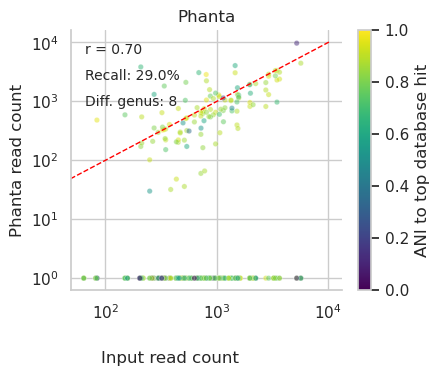

In [25]:
# phanta (Figure 5B)
import polars as pl
import math
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

df_lst = []

for i in range(11, 15):
    # each point represents on input genome
    # color of each point is ani to top database genome
    # x-axis is input genome coverage
    # y-axis is coverage of a phanta genome assigned to most similar input genome

    # read coverage file
    input_genomes = (
        pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'}) # load input coverage
            .join(pl.read_csv('markermagu/combined_renamed_v_tgvg.anicalc.tsv', separator='\t'), on='qname', how='left') # join with ani calcs
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'), # calculate ani of inputs (qname) to uhvdb (tname)
            ])
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # identify qani to top uhvdb genome
            .fill_null(0.0) # fill in non-matching genomes with ani of 0
    )

    # load phanta data
    phanta_top_hit = (
        pl.read_csv(f'uhvdb_phanta/results/classification/split_{i}.krak.report.filtered.bracken.scaled', separator='\t', ignore_errors=True) # load phanta data
            .rename({'name':'contig_id'})
            .with_columns([
                (pl.col('new_est_reads') *2).alias('phanta_read_count'), # double for paired end
            ])
            .join(
                pl.read_csv('uhvdb_phanta/votus_metadata.tsv', ignore_errors=True, separator='\t')
                    .rename({'uhgv_genome': 'Genome Name', 'uhgv_votu':'lineage'})[['Genome Name', 'lineage']],
                left_on='contig_id',
                right_on='lineage',
                how='left'
            )
            .join(pl.read_csv('uhvdb_phanta/combined_renamed_v_votus_hq_plus.anicalc.tsv', separator='\t'), left_on='Genome Name', right_on='tname', how='left') # keep blast data for phanta hits
            .filter(pl.col('qname').is_in(set(input_genomes['qname']))) # filter blast to only phanta v input genomes
            .with_columns([
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani') # calculate ani of phanta (contig_id) to input genomes (qname)
            ])
            .sort('tani', descending=True)  # identify most similar input genome for each phanta genome
            .unique('contig_id', maintain_order=True) # keep only top input per phanta genome
            [['contig_id', 'qname', 'phanta_read_count']]
    )

    # assign phanta coverages to input genome
    input_w_phanta = (
        input_genomes
            .join(phanta_top_hit, on='qname', how='full') # add phanta data to input genomes
            .sort('qani', descending=True)
            .unique('qname', maintain_order=True) # if multiple phanta to an input, keep only phanta for top database hit
            .fill_null(1) # fill missing phanta hits with coverage of 0.1
    )

    if i <= 10:
        body_site = "gut"
    elif i < 15:
        body_site = "oral"
    elif i < 17:
        body_site = "skin"
    else:
        body_site = "urogenital"
    
    final_df = (
        input_w_phanta
            .with_columns([
                pl.lit(body_site).alias('body_site')
            ])
    )

    df_lst.append(final_df)

# create dataframe
df = (
    pl.concat(df_lst)
)


print("Detected species > 0x-",
    "gut:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('phanta_read_count') > 1) & (pl.col('body_site') == 'urogenital')).unique('qname').shape[0]
)
print("Total species > 0x -",
    "gut:", df.filter((pl.col('body_site') == 'gut')).unique('qname').shape[0],
    "oral:", df.filter((pl.col('body_site') == 'oral')).unique('qname').shape[0],
    "skin:", df.filter((pl.col('body_site') == 'skin')).unique('qname').shape[0],
    "urogenital:", df.filter((pl.col('body_site') == 'urogenital')).unique('qname').shape[0],
)

print("False hits:", df.filter((pl.col('qani') < 0.6) & (pl.col('phanta_read_count') > 1)).unique('contig_id').shape[0])

print("R-squared:", pearsonr(df.filter((pl.col('phanta_read_count') > 1))['read_count'].to_list(), df.filter((pl.col('phanta_read_count') > 1))['phanta_read_count'].to_list()))

# plot breadth results
df = df.rename({'phanta_read_count':'Phanta read count', 'read_count':'Input read count'})
sns.set(style="whitegrid")
g = sns.FacetGrid(df, col="body_site", margin_titles=True)
g.map_dataframe(sns.scatterplot, 'Input read count', 'Phanta read count', data=df, s=15, alpha=0.5, hue='qani', palette='viridis', hue_norm=(0, 1))

# Add dynamic 1:1 line for each facet
def one_to_one_line(data, **kwargs):
    ax = plt.gca()
    # Get combined limits across both axes
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, "--", color="red", linewidth=1)

# Apply to each facet
g.map_dataframe(one_to_one_line)

# Apply log scales safely
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

# Add a single colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes.ravel(), label="ANI to top database hit")

# Remove individual x-axis labels
for ax in g.axes.flat:
    ax.set_xlabel('')

# Add one shared x-axis label
g.fig.text(0.5, 0.04, 'Input read count', ha='center', fontsize=12)

# display r-squared on plot
for ax in g.axes.flat:
    body_site = ax.get_title().split(' = ')[1]
    r_squared = pearsonr(
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Input read count'].to_list(),
        df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site))['Phanta read count'].to_list()
    )[0]
    ax.text(0.05, 0.95, f'r = {r_squared:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    tp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('body_site') == body_site)).unique('qname').height
    fp = df.filter((pl.col('Phanta read count') > 1) & (pl.col('qani') < 0.6) & (pl.col('body_site') == body_site)).unique('qname').height
    total = df.filter((pl.col('body_site') == body_site)).unique('qname').height
    recovery = tp / total * 100
    ax.text(0.05, 0.85, f'Recall: {recovery:.1f}%', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')
    ax.text(0.05, 0.75, f'Diff. genus: {fp}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top')

# increase plot size`
g.fig.set_size_inches(6, 4)

# remove body site titles
for ax in g.axes.flat:
    ax.set_title('Phanta')

plt.show()